# CIFAR10 DATASET

In [ ]:
pip install PEFT

In [ ]:
pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 55.0 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
from pathlib import Path
import torch
from PIL import Image
from peft import get_peft_model,LoraConfig
from transformers import ViTForImageClassification
from transformers import ViTImageProcessor
from pathlib import Path
from peft import LoraConfig
from peft import get_peft_model

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
import tqdm
def get_image_paths(x): # Input(Original Folder Path) --> O/P (List of all file paths)
    a = []
    ext = ['*.jpg','*.png','*.jfif']
    for i in ext:
        for j in tqdm.tqdm(list(x.rglob(i))):
            a.append(j)
    return a

In [ ]:
def build_samples(paths):  # Input(file_paths) --> O/P(Meta dataset {path,label,id})
    samples = []
    for i in tqdm.tqdm(paths):
        samples.append(
            {
                'path':i,
                'label':i.parent.name,
                #Split is optional for this example
                'id':i.stem
            }
        )
    return samples

In [ ]:
def count_labels(sample):  # Input(Meta Dataset) --> O/P ({class:frequency})
    labels = {}
    for i in samples:
        if i['label'] not in labels:
            labels[i['label']] = 1
        else:
            labels[i['label']] += 1

    return labels

In [ ]:
def encoding(sample):

  labels = []

  for i in sample:
    labels.append(i['label'])
  unique_labels = set(labels) # It has no inherent ordering so we have to sort it first and then apply encoding else inconsistency can arise

  print()
  print("Number of labels: ",len(labels))
  print("Unique labels: ",unique_labels)

  label_to_id = {}
  id_to_label = {}

  unique_labels = sorted(unique_labels)
  print("Sorted labels: ",unique_labels)

  for id,label in enumerate(unique_labels):
    label_to_id[label] = id
    id_to_label[id] = label

  return label_to_id , id_to_label

#label_to_id , id_to_label = encoding(samples)

#print('Label to id: ',label_to_id)
#print('Id to Label: ',id_to_label)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Copy the zip file from Drive to local Colab storage
!cp /content/drive/MyDrive/cifar10.zip /content/cifar10.zip

# Unzip the file into a local folder named cat_dog
!unzip -q /content/cifar10.zip -d /content/cifar10


In [ ]:
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224"
)
processor = ViTImageProcessor.from_pretrained(
    "google/vit-base-patch16-224"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

In [ ]:
data = Path('/content/cifar10')
image_paths = get_image_paths(data)
print(image_paths[:5])

0it [00:00, ?it/s]
100%|██████████| 60000/60000 [00:00<00:00, 2574614.20it/s]
0it [00:00, ?it/s]

[PosixPath('/content/cifar10/test/dog/4530_dog.png'), PosixPath('/content/cifar10/test/dog/1117_dog.png'), PosixPath('/content/cifar10/test/dog/9225_dog.png'), PosixPath('/content/cifar10/test/dog/8729_dog.png'), PosixPath('/content/cifar10/test/dog/1548_dog.png')]


In [ ]:
samples = build_samples(image_paths)
print()
print(samples[:3])

100%|██████████| 60000/60000 [00:00<00:00, 358587.13it/s]


[{'path': PosixPath('/content/cifar10/test/dog/4530_dog.png'), 'label': 'dog', 'id': '4530_dog'}, {'path': PosixPath('/content/cifar10/test/dog/1117_dog.png'), 'label': 'dog', 'id': '1117_dog'}, {'path': PosixPath('/content/cifar10/test/dog/9225_dog.png'), 'label': 'dog', 'id': '9225_dog'}]


In [ ]:
count = count_labels(samples)
for i,j in count.items():
    print(f'{i} : {j}')

dog : 6000
ship : 6000
bird : 6000
horse : 6000
truck : 6000
deer : 6000
cat : 6000
airplane : 6000
frog : 6000
automobile : 6000


In [ ]:
label_to_id , id_to_label = encoding(samples)

print('Label to id: ',label_to_id)
print('Id to Label: ',id_to_label)


Number of labels:  60000
Unique labels:  {'horse', 'frog', 'cat', 'dog', 'deer', 'airplane', 'automobile', 'ship', 'truck', 'bird'}
Sorted labels:  ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Label to id:  {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}
Id to Label:  {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}


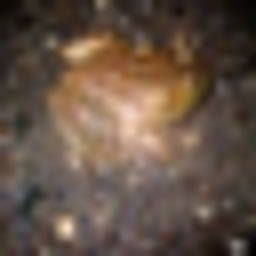

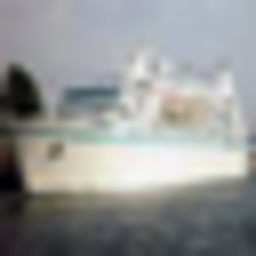

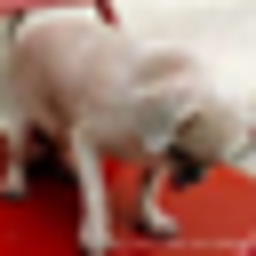

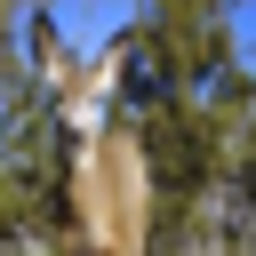

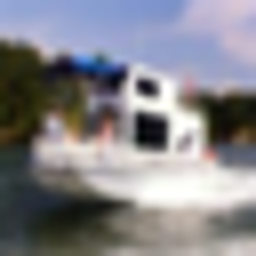

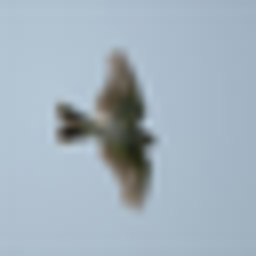

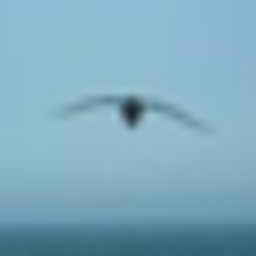

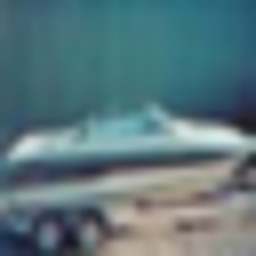

In [ ]:
import numpy as np
from PIL import Image
for i in range(2):
  for j in np.random.choice(range(0+i*12500,12500*(i+1)),4):
    with Image.open(samples[j]['path']) as img:

      display(img.resize((256,256)))

In [ ]:
from sklearn.model_selection import train_test_split

labels = [i['label'] for i in samples]
trainx,testx,trainy,_ = train_test_split(samples,labels,test_size=0.15,shuffle = True,stratify = labels,random_state = 42)

trainx,validx,_,_ = train_test_split(trainx,trainy,test_size=0.1,shuffle = True,stratify = trainy,random_state = 36)

print("Number of training data ",len(trainx))
print("Number of validation data ",len(validx))
print("Number of test data ",len(testx))

Number of training data  45900
Number of validation data  5100
Number of test data  9000


In [ ]:
import random
from torch.utils.data import Dataset,DataLoader,Subset
import torchvision

train_augmentation = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(p = 0.5),
    torchvision.transforms.RandomRotation(45),
    torchvision.transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2,hue=0.1),# Randomly shifts the brightness, contrast,saturation, and hue
    torchvision.transforms.RandomGrayscale(p=0.1) # # 10% chance to strip all color
    # We don't want to use imagenet stats(mean and std) rather use stats provided by vit preprocessor with which model is trained(weight mismatch , performance drop can happen as model is optimized for some other stats)
])
# the augmentations can be applied on image data even before converting into tensor
valid_augmentation = torchvision.transforms.Compose([
    torchvision.transforms.Resize((256,256)),
    torchvision.transforms.CenterCrop(224) # Purely deterministic cropping but if image is <224,problems occur hence resize done first
])


from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

class CustomDataset(Dataset):

  def __init__(self,samples,labeltoid,transform = None):
    self.sample = samples
    self.label2id = labeltoid
    self.transform = transform

  def __len__(self):
    return len(self.sample)

  def __getitem__(self,index):

    try:
      if self.transform is None:

          with Image.open(self.sample[index]['path']) as img:

            img = img.convert('RGB')

            return tensor,self.label2id[self.sample[index]['label']]

      else:
          with Image.open(self.sample[index]['path']) as img:

            img = img.convert('RGB')
            tensor = self.transform(img)
            return tensor,self.label2id[self.sample[index]['label']]

    except Exception:
        # If any image fails to load , simply pick any random index of any image

        idx = random.choice(range(len(self.sample)))
        return self.__getitem__(idx)


training_dataset = CustomDataset(trainx,label_to_id,transform = train_augmentation)
validation_dataset = CustomDataset(validx,label_to_id,transform=valid_augmentation)
test_dataset = CustomDataset(testx,label_to_id,transform = valid_augmentation)

print('Original Label ',trainx[0]['label'])
print('Label to Id: ',label_to_id)
print('Tensor and Label wrapped in single unit: \n',training_dataset[0])  # Tuple of tensor and label together
print('Label: ',training_dataset[0][1])


Original Label  horse
Label to Id:  {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}
Tensor and Label wrapped in single unit: 
 (<PIL.Image.Image image mode=RGB size=32x32 at 0x7B9916CE3380>, 7)
Label:  7


In [ ]:
def collate_fn(batch,processor):

  # batch is a list of tuples: [(text_tensor, label), (text_tensor, label), ...]

  # images = [processor(i[0])['pixel_values'] for i in batch] -> O/P will be images = [tensor(3, 224, 224), tensor(3, 224, 224)..]
  # What we need: tensor(batch, 3, 224, 224) shape : [batch_size,3,224,224], automatically done by return_tensors = 'pt'

  images = [i[0] for i in batch]
  labels = [i[1] for i in batch]

  return processor(images,return_tensors='pt')['pixel_values'],torch.tensor(labels)

In [ ]:
train_loader = DataLoader(training_dataset,shuffle = True,batch_size = 32,num_workers=2,prefetch_factor=2,pin_memory=True,collate_fn = lambda x,p = processor: collate_fn(x,p))
val_loader = DataLoader(validation_dataset,shuffle = True,batch_size = 32,num_workers=2,prefetch_factor=2,pin_memory=True,collate_fn = lambda x,p = processor: collate_fn(x,p))
test_loader = DataLoader(test_dataset,shuffle = True,batch_size = 32,num_workers=2,prefetch_factor=2,pin_memory=True,collate_fn = lambda x,p=processor: collate_fn(x,p))

#Dataloader only provides batch to collate_fn , hence lambda x where x is the batch and inside lambda,there is my collate_fn(x,processor)
print("Training Batches ",len(train_loader))
print("Validation Batches ",len(val_loader))
print("Test Batches ",len(test_loader))

# Use 2 cores and fetch 2 batches in advance

Training Batches  1435
Validation Batches  160
Test Batches  282


In [ ]:
print(model)

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

In [ ]:
#model.classifier.out_features=2 It changes the attribute or variable inside model object but don't change the weight matrix(768,1000)->(768,2)
print("After doing model.classifier.out_features=2 , shape is : ",model.classifier.weight.shape) # not (2,768)

for param in model.parameters():
  param.requires_grad = False

model.classifier = torch.nn.Linear(model.config.hidden_size,10,bias = True)
model.config.num_labels = 10 # So that loss function inside the model works for 2 classes

print("Classifier weight trainable ",model.classifier.weight.requires_grad)
print("Classifier Bias Trainable ",model.classifier.bias.requires_grad)
print("After changing the Linear layer of classifier , shape: ",model.classifier.weight.shape)

After doing model.classifier.out_features=2 , shape is :  torch.Size([1000, 768])
Classifier weight trainable  True
Classifier Bias Trainable  True
After changing the Linear layer of classifier , shape:  torch.Size([10, 768])


In [ ]:
for i,param in model.named_parameters():
  print(f"{i} {'-'*50} Trainable : {param.requires_grad}")

base_model.model.vit.embeddings.cls_token -------------------------------------------------- Trainable : False
base_model.model.vit.embeddings.position_embeddings -------------------------------------------------- Trainable : False
base_model.model.vit.embeddings.patch_embeddings.projection.weight -------------------------------------------------- Trainable : False
base_model.model.vit.embeddings.patch_embeddings.projection.bias -------------------------------------------------- Trainable : False
base_model.model.vit.layers.0.attention.q_proj.base_layer.weight -------------------------------------------------- Trainable : False
base_model.model.vit.layers.0.attention.q_proj.base_layer.bias -------------------------------------------------- Trainable : False
base_model.model.vit.layers.0.attention.q_proj.lora_A.default.weight -------------------------------------------------- Trainable : False
base_model.model.vit.layers.0.attention.q_proj.lora_B.default.weight -------------------------

In [ ]:
config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj","k_proj","v_proj","o_proj"],
    lora_dropout=0.1
)

model = get_peft_model(
    model,
    config
)
model = model.to(device)


In [ ]:
# Specifications
import warnings

warnings.filterwarnings('ignore')

import time
optimizer = torch.optim.AdamW(model.parameters(),lr = 3e-4 , weight_decay= 1e-4) # Large LR initially → gradually decrease smoothly.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max = 20)
from tqdm.auto import tqdm

def Trainer(epochs,thres,patience):

  train_loss = []
  val_loss = []
  training_acc = []
  validation_acc = []
  current_best = float('inf')

  scheduler.T_max = epochs # T_max is max no of epochs

  if Path("best_model_classifier_vit.pth").exists():
    model.load_state_dict(
      torch.load("best_model_classifier_vit.pth",map_location=device)
    )
  p = 0

  for epoch in range(epochs):

    t1 = time.time()
    train_samples = 0
    val_samples = 0
    train_acc = val_acc = 0
    training_loss = validation_loss = 0

    model.train()

    for images,labels in tqdm(train_loader):

      images,labels = images.to(device),labels.to(device)
      optimizer.zero_grad()

      output = model(images,labels) #Loss can only be calculated if there are labels
      train_acc += torch.sum(torch.argmax(output.logits,dim=1) == labels ).item()
      train_samples += len(labels)
      loss = output.loss
      loss.backward()
      optimizer.step()
      training_loss += loss.item()

    model.eval()

    with torch.no_grad():

      for images,labels in tqdm(val_loader):

          images,labels = images.to(device),labels.to(device)
          output = model(images,labels)
          val_acc += torch.sum(torch.argmax(output.logits,dim=1) == labels ).item()
          val_samples += len(labels)
          loss = output.loss
          validation_loss += loss.item()

    training_acc.append(train_acc/train_samples)
    validation_acc.append(val_acc/val_samples)
    train_loss.append(training_loss/len(train_loader))
    val_loss.append(validation_loss/len(val_loader))
    print()
    print(f"Epoch: {epoch+1} || Training Loss: {(training_loss/len(train_loader)):.4f} || Validation Loss: {(validation_loss/len(val_loader)):.4f} || Training Accuracy: {(train_acc/train_samples):.4f} Validation Accuracy: {(val_acc/val_samples):.4f} Time: {(time.time()-t1):.2f}s")
    # len(train_loader) is total batches

    if val_loss[-1] < (current_best - thres) :

      p = 0
      current_best = val_loss[-1]
      print(" Saving the Current Best Model ------")
      torch.save(model.state_dict(),'best_model_classifier_vit.pth')

    else:
      p += 1
      if p == patience:
        break
    scheduler.step()

  return train_loss,val_loss,training_acc,validation_acc


In [ ]:
metrics = Trainer(4,1e-6,3)

  0%|          | 0/1435 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]


Epoch: 1 || Training Loss: 0.4216 || Validation Loss: 0.0729 || Training Accuracy: 0.8632 Validation Accuracy: 0.9790 Time: 1374.62s
 Saving the Current Best Model ------


  0%|          | 0/1435 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

...

  0%|          | 0/160 [00:00<?, ?it/s]


Epoch: 3 || Training Loss: 0.1630 || Validation Loss: 0.0531 || Training Accuracy: 0.9468 Validation Accuracy: 0.9845 Time: 1381.80s
 Saving the Current Best Model ------


  0%|          | 0/1435 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]


Epoch: 4 || Training Loss: 0.1392 || Validation Loss: 0.0446 || Training Accuracy: 0.9533 Validation Accuracy: 0.9845 Time: 1362.16s
 Saving the Current Best Model ------


  0%|          | 0/282 [00:00<?, ?it/s]


Average Loss across all batches: 0.05350321903824806
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

    airplane       0.99      0.98      0.98       900
  automobile       0.99      1.00      0.99       900
        bird       0.98      0.99      0.98       900
         cat       0.96      0.95      0.96       900
        deer       0.99      0.98      0.99       900
         dog       0.96      0.98      0.97       900
        frog       0.99      0.99      0.99       900
       horse       0.99      0.99      0.99       900
        ship       0.99      0.99      0.99       900
       truck       0.99      0.99      0.99       900

    accuracy                           0.98      9000
   macro avg       0.98      0.98      0.98      9000
weighted avg       0.98      0.98      0.98      9000



<Axes: >

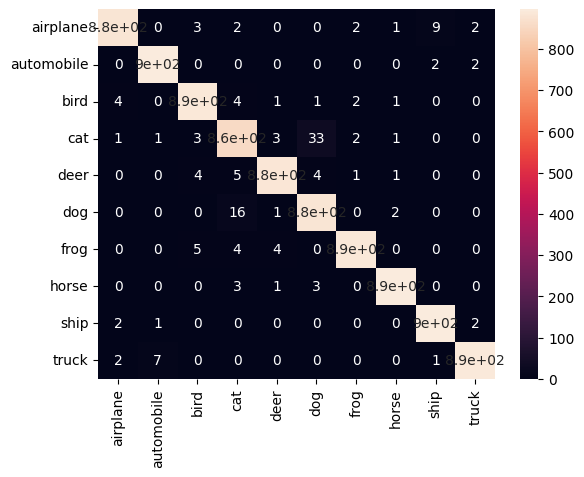

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns

target_names = [id_to_label[i] for i in sorted(id_to_label.keys())]
model.load_state_dict(
    torch.load("best_model_classifier_vit.pth",map_location=device)
)
model.eval()
with torch.no_grad():
  output = []
  ytrue = []
  test_loss = []
  for images,labels in tqdm(test_loader):
    images,labels = images.to(device),labels.to(device)

    out = model(images,labels)
    output.extend(torch.argmax(out.logits,dim=1).cpu().tolist())
    ytrue.extend(labels.cpu().tolist())
    loss = out.loss
    test_loss.append(loss.item())
  print()
  print(f"Average Loss across all batches: {torch.sum(torch.tensor(test_loss))/len(test_loader)}")
print('-'*100)
print(classification_report(ytrue,output,target_names=target_names))

sns.heatmap(confusion_matrix(ytrue,output),annot=True, xticklabels = target_names, yticklabels = target_names)

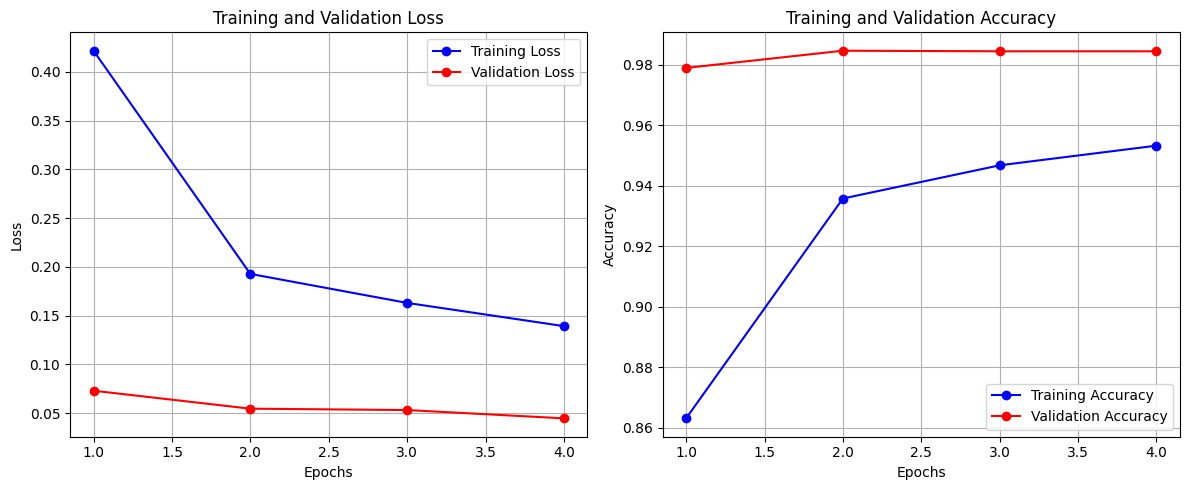

In [ ]:
import matplotlib.pyplot as plt

train_loss, val_loss, training_acc, validation_acc = metrics # Unpack the metrics from the Trainer function

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, training_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, validation_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Finding misclassified images:   0%|          | 0/282 [00:00<?, ?it/s]

Found 149 misclassified images.


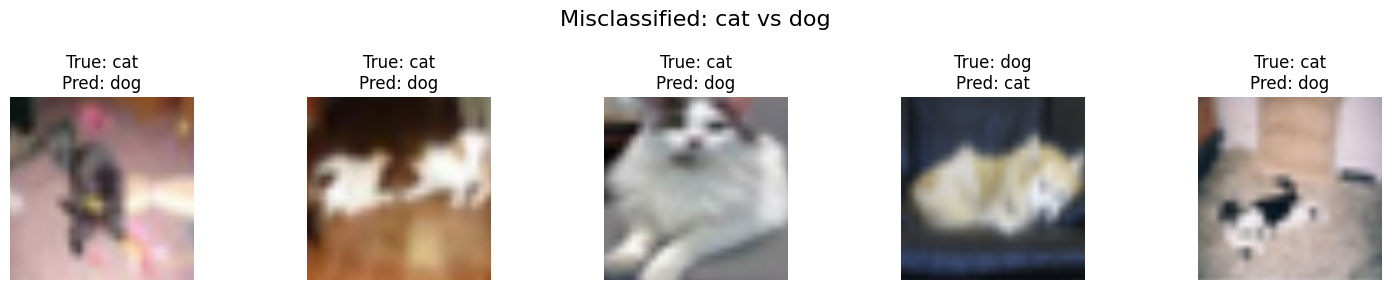

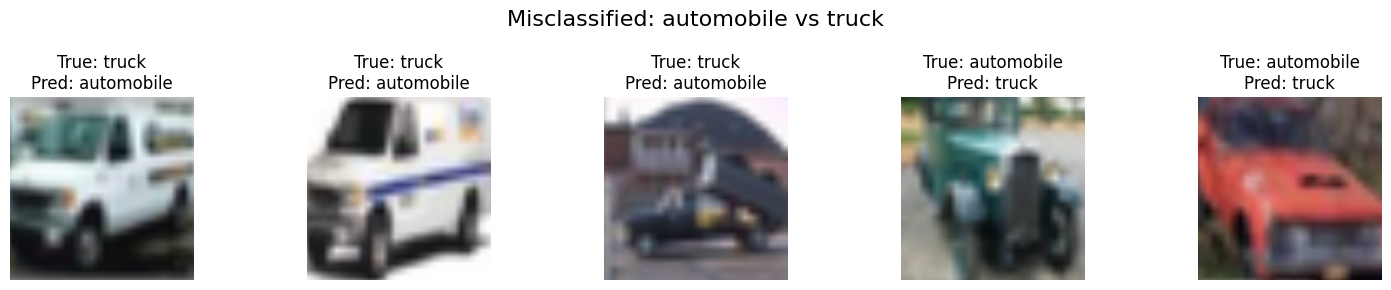

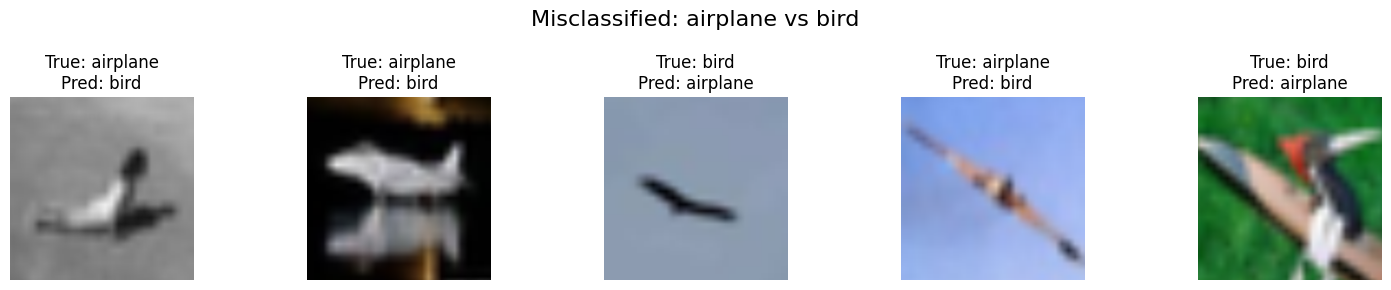

In [ ]:
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

misclassified_images = []

model.eval()
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Finding misclassified images"): # Use the pre-defined test_loader
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        predictions = torch.argmax(outputs.logits, dim=1)

        for i in range(len(labels)):
            if predictions[i] != labels[i]:
                misclassified_images.append({
                    'image_tensor': images[i].cpu(),
                    'true_label': id_to_label[labels[i].item()],
                    'predicted_label': id_to_label[predictions[i].item()]
                })

print(f"Found {len(misclassified_images)} misclassified images.")

def display_misclassified_pairs(misclassified_list, label_map, pair_type, max_display=5):
    count = 0
    fig = plt.figure(figsize=(15, 3 * ((max_display + 4) // 5)))
    plt.suptitle(f"Misclassified: {pair_type[0]} vs {pair_type[1]}", fontsize=16)

    for img_data in misclassified_list:
        true_label_name = img_data['true_label']
        predicted_label_name = img_data['predicted_label']

        if (true_label_name == pair_type[0] and predicted_label_name == pair_type[1]) or \
           (true_label_name == pair_type[1] and predicted_label_name == pair_type[0]):

            if count >= max_display: # Limit the number of images to display
                break

            img_tensor = img_data['image_tensor']
            # Denormalize the image for display (assuming ViTImageProcessor default norm)
            mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
            std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
            display_img = (img_tensor * std) + mean
            display_img = torch.clamp(display_img, 0, 1) # Clip to ensure valid pixel range

            plt.subplot(((max_display + 4) // 5), 5, count + 1)
            plt.imshow(display_img.permute(1, 2, 0)) # Convert from C,H,W to H,W,C for matplotlib
            plt.title(f"True: {true_label_name}\nPred: {predicted_label_name}")
            plt.axis('off')
            count += 1

    if count == 0:
        print(f"No misclassified images found for {pair_type[0]} vs {pair_type[1]}")
        plt.close(fig) # Close empty figure
    else:
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
        plt.show()

# Define the pairs of interest
pairs_to_visualize = [
    ('cat', 'dog'),
    ('automobile', 'truck'),
    ('airplane', 'bird')
]

for p_type in pairs_to_visualize:
    display_misclassified_pairs(misclassified_images, id_to_label, p_type, max_display=5)

In [ ]:
!cp best_model_classifier_vit.pth /content/drive/MyDrive/  # Saving my Model in drive

!ls /content/drive/MyDrive/ | grep vit

best_model_classifier_vit.pth
vit_dataset_clean
